In [7]:
from pathlib import Path
import numpy as np
import torch
import matplotlib.pyplot as plt

from IPPy import operators
from IPPy.solvers import ChambollePockTpVConstrained
from IPPy.utilities import normalize, save_image
from IPPy.utilities.metrics import PSNR, SSIM, RE

from utils.data_utils import load_normalized_image

# Input
TEST_DIR = Path("../dataset_resized/test_resized")
SINOGRAMS_DIR = Path("../sinograms")

# Output ricostruzioni TV
TV_DIR = Path("../reconstructions/tv")
TV_DIR.mkdir(parents=True, exist_ok=True)

# Stessa configurazione angolare usata in 02_synogram_generation,
# necessaria per ricostruire lo stesso operatore K con cui e' stato generato il sinogramma
ANGLE_CONFIGS = {
    90: np.linspace(-45, 45, 90),
    45: np.linspace(-45, 45, 45),
    30: np.linspace(-30, 30, 32)[1:-1],
    15: np.linspace(-30, 30, 17)[1:-1],
}

NOISE_LEVEL = 0.005
IMG_SIZE = (256, 256)

# Prova su una singola configurazione angolare, poi si estende alle altre
N_ANGLES = 90


K = operators.CTProjector(
    img_shape=IMG_SIZE,
    angles=np.deg2rad(ANGLE_CONFIGS[N_ANGLES]),
    geometry="parallel",
    force_cpu=True,
)


Attempting to create ASTRA projector type: 'linear' for 'parallel' geometry...
Successfully created ASTRA projector type: 'linear'
CTProjector initialized. Geometry: parallel. Using GPU: False. FBP Algorithm: FBP


In [8]:
# Prima immagine disponibile nel test set per la configurazione scelta
sino_path = sorted((SINOGRAMS_DIR / "test" / str(N_ANGLES)).rglob("*.npy"))[0]
rel_path = sino_path.relative_to(SINOGRAMS_DIR / "test" / str(N_ANGLES))
gt_path = (TEST_DIR / rel_path).with_suffix(".png")

print("Sinogramma:", sino_path)
print("GT:", gt_path)

# Sinogramma rumoroso -> tensor (1, 1, n_angoli, det_size)
sinogram = np.load(sino_path)
y_delta = torch.from_numpy(sinogram).float().unsqueeze(0).unsqueeze(0)

# Immagine di riferimento -> tensor (1, 1, 256, 256), [0, 1]
gt = load_normalized_image(gt_path)
x_true = torch.from_numpy(gt).float().unsqueeze(0).unsqueeze(0)

Sinogramma: ..\sinograms\test\90\C081\0.npy
GT: ..\dataset_resized\test_resized\C081\0.png


In [9]:
# Parametro di regolarizzazione TV, punto di partenza da tarare
lambda_tv = 5e-2

# Raggio del vincolo di discrepanza, coerente con IPPy.utilities.gaussian_noise
# (||e|| = NOISE_LEVEL * ||y||, stesso rumore usato in fase di generazione dei sinogrammi)
epsilon = NOISE_LEVEL * torch.norm(y_delta)

solver = ChambollePockTpVConstrained(K)

x_sol, info = solver(
    y_delta,
    epsilon=epsilon,
    lmbda=lambda_tv,
    x_true=x_true,
    starting_point=torch.zeros_like(x_true),
    maxiter=200,
    p=1,
    verbose=True,
)

print(f"Iterazioni: {info['iterations']}")
print(f"RE: {info['RE'][-1].item():.4f} | PSNR: {info['PSNR'][-1].item():.2f} dB | SSIM: {info['SSIM'][-1].item():.4f}")

# IPPy.operators.Operator.T() forza requires_grad_(True) sull'adjoint,
# quindi x_sol e le serie in info arrivano con un grafo autograd attaccato
# anche se l'algoritmo non fa backprop. Va staccato prima di plot/salvataggio.
x_sol = x_sol.detach()

(00:00:00) Iteration 1/200 -> RE: 0.7114, SSIM: 0.2961.
(00:00:00) Iteration 2/200 -> RE: 0.6588, SSIM: 0.3240.
(00:00:00) Iteration 3/200 -> RE: 0.6187, SSIM: 0.3534.
(00:00:00) Iteration 4/200 -> RE: 0.5934, SSIM: 0.3854.
(00:00:00) Iteration 5/200 -> RE: 0.5782, SSIM: 0.4218.
(00:00:00) Iteration 6/200 -> RE: 0.5649, SSIM: 0.4139.
(00:00:00) Iteration 7/200 -> RE: 0.5482, SSIM: 0.4187.
(00:00:00) Iteration 8/200 -> RE: 0.5283, SSIM: 0.4285.
(00:00:01) Iteration 9/200 -> RE: 0.5085, SSIM: 0.4430.
(00:00:01) Iteration 10/200 -> RE: 0.4918, SSIM: 0.4578.
(00:00:01) Iteration 11/200 -> RE: 0.4795, SSIM: 0.4712.
(00:00:01) Iteration 12/200 -> RE: 0.4707, SSIM: 0.4808.
(00:00:01) Iteration 13/200 -> RE: 0.4644, SSIM: 0.4864.
(00:00:01) Iteration 14/200 -> RE: 0.4603, SSIM: 0.4891.
(00:00:01) Iteration 15/200 -> RE: 0.4581, SSIM: 0.4893.
(00:00:01) Iteration 16/200 -> RE: 0.4577, SSIM: 0.4900.
(00:00:01) Iteration 17/200 -> RE: 0.4589, SSIM: 0.4913.
(00:00:01) Iteration 18/200 -> RE: 0.461

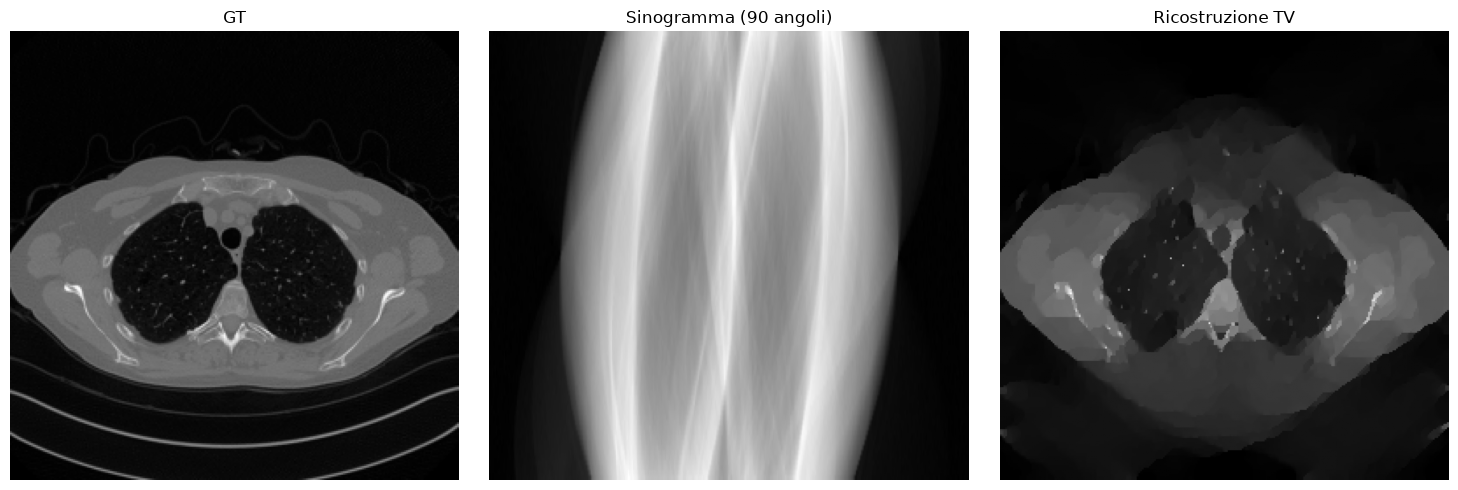

In [10]:
fig, axs = plt.subplots(1, 3, figsize=(15, 5))

axs[0].imshow(x_true[0, 0], cmap="gray")
axs[0].set_title("GT")
axs[0].axis("off")

axs[1].imshow(y_delta[0, 0], cmap="gray", aspect="auto")
axs[1].set_title(f"Sinogramma ({N_ANGLES} angoli)")
axs[1].axis("off")

axs[2].imshow(x_sol[0, 0].detach(), cmap="gray")
axs[2].set_title("Ricostruzione TV")
axs[2].axis("off")

plt.tight_layout()
plt.show()

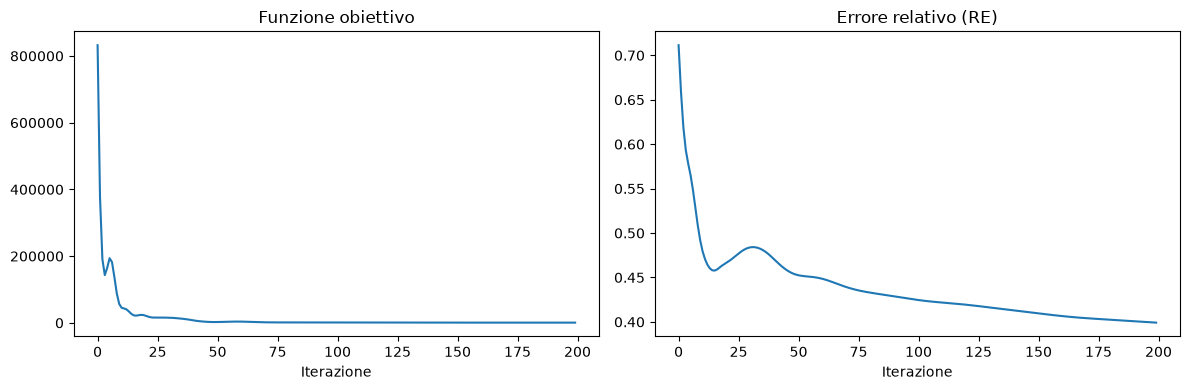

In [11]:
fig, axs = plt.subplots(1, 2, figsize=(12, 4))

axs[0].plot(info["obj"].detach())
axs[0].set_title("Funzione obiettivo")
axs[0].set_xlabel("Iterazione")

axs[1].plot(info["RE"].detach())
axs[1].set_title("Errore relativo (RE)")
axs[1].set_xlabel("Iterazione")

plt.tight_layout()
plt.show()

In [13]:
out_path = (TV_DIR / str(N_ANGLES) / rel_path).with_suffix(".png")
out_path.parent.mkdir(parents=True, exist_ok=True)
save_image(normalize(x_sol), out_path)
print("Salvato in:", out_path)

Salvato in: ..\reconstructions\tv\90\C081\0.png
